## Notebook roadmap
This notebook reproduces **SM Figure 1** (migrated from old `figure_2_fisher_info_ablation.ipynb`).

Figure intent:
- compare learned nearest-neighbor susceptibility curves across sample-size ablations,
- overlay overlap-derived theory baselines for three divergences,
- export one supplementary PDF per divergence under `./sm_figures/`.


In [7]:
import os
import pickle

import numpy as np
import torch as pt

%matplotlib widget
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

from nestconf import Configurable
from typing import Tuple

from utils.aggregation import aggregate_seeded_results


# Common settings
Set global typography and axis style for consistent supplementary-figure rendering.


In [8]:
AXES_LINEWIDTH = 1.0
TICK_SIZE = 8
LABEL_SIZE = 9

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'text.latex.preamble': '\n'.join([
        r'\usepackage[semibold,sfdefault]{libertine}',
        r'\usepackage[libertine]{newtxmath}',
    ]),
    'axes.linewidth': AXES_LINEWIDTH,
})


# Load data
Load localized top-level artifacts only (no nested training folders).


In [9]:
class Experiment(Configurable):
    """Schema for pickled experiment-config keys in TFIM sample-ablation assets."""

    system_size: int = None
    bases_to_include: Tuple = None
    samples_per_point: int = 10000
    hidden_size: int = 64
    bootstrap: int = 1
    bootstrap_size: int = None
    use_deepset_encoding: bool = None


with open('../data/figures/sm_figure_1/system_size2small_window_large_systems_overlaps.pickle', 'rb') as handle:
    system_size2overlaps = pickle.load(handle)

figure_data_dir = '../data/figures/sm_figure_1/sample_ablation'
with open(os.path.join(figure_data_dir, 'seeded_f_matrices_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'seeded_f_matrices_std_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_std_dict = pickle.load(handle)
with open(os.path.join(figure_data_dir, 'coords_dict.pickle'), 'rb') as handle:
    coords_dict = pickle.load(handle)


## Aggregate seeded divergence matrices
Aggregate all seed realizations with manuscript-stable settings (`use_inverse_variance_weighting=False`).


In [10]:
f_matrices_dict = {}
f_matrices_std_dict = {}
for exp_config in seeded_f_matrices_dict:
    f_matrices_dict[exp_config] = {}
    f_matrices_std_dict[exp_config] = {}

    for divergence in seeded_f_matrices_dict[exp_config]:
        f_matrix, f_matrix_std, _, _ = aggregate_seeded_results(
            seeded_f_tensors=list(seeded_f_matrices_dict[exp_config][divergence].values()),
            seeded_std_tensors=list(seeded_f_matrices_std_dict[exp_config][divergence].values()),
            verbose=True,
            use_inverse_variance_weighting=False,
        )
        f_matrices_dict[exp_config][divergence] = f_matrix
        f_matrices_std_dict[exp_config][divergence] = f_matrix_std

# Keep deterministic order of sample-size columns.
sample_sizes = sorted({exp_config.samples_per_point for exp_config in f_matrices_dict})
num_sample_sizes = len(sample_sizes)

divergence2theory_multiplier = {
    'hellinger': 1.0,
    'triangular': 2.0,
    'jensen_shannon': 0.5,
}

divergence2label = {
    'hellinger': 'Hellinger',
    'triangular': 'Le Cam',
    'jensen_shannon': 'Jensen-Shannon',
}


Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results from 27 seeds.
Aggregating results 

## Plot helper
Use compact endpoint tick labels to keep narrow panels readable.


In [11]:
def compact_axes(ax, *, x_tex=None, xmin_label=None, xmax_label=None):
    """Format x-axis with endpoint numeric labels and a symbolic midpoint label."""

    xmin, xmax = ax.get_xlim()
    xmid = 0.5 * (xmin + xmax)

    def x_major_formatter(value, _):
        if np.isclose(value, xmin) and xmin_label is not None:
            return xmin_label
        if np.isclose(value, xmax) and xmax_label is not None:
            return xmax_label
        return x_tex or ''

    ax.xaxis.set_ticks([xmin, xmid, xmax])
    ax.xaxis.set_major_formatter(FuncFormatter(x_major_formatter))
    ax.xaxis.set_minor_locator(AutoMinorLocator())

    ax.tick_params(
        axis='x', which='major',
        labelsize=LABEL_SIZE,
        direction='in',
        bottom=True, top=False,
        length=4, pad=1,
    )
    ax.tick_params(
        axis='x', which='minor',
        labelsize=LABEL_SIZE,
        direction='in',
        bottom=True, top=False,
        length=3, pad=1,
    )


# Build and export figure
Render one panel-row figure per divergence and save `sm_figure_1_<divergence>.pdf`.


/var/folders/xs/ft410byd4qb226jqk7qd4mq40000gp/T/ipykernel_32080/1931178487.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('magma')(np.linspace(0.0, 0.9, max(len(selected_exp_configs), 1)))
/var/folders/xs/ft410byd4qb226jqk7qd4mq40000gp/T/ipykernel_32080/1931178487.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('magma')(np.linspace(0.0, 0.9, max(len(selected_exp_configs), 1)))
/var/folders/xs/ft410byd4qb226jqk7qd4mq40000gp/T/ipykernel_32080/1931178487.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplot

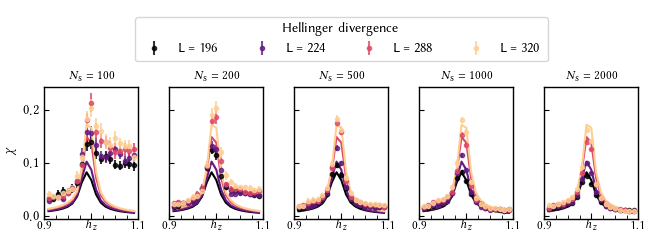

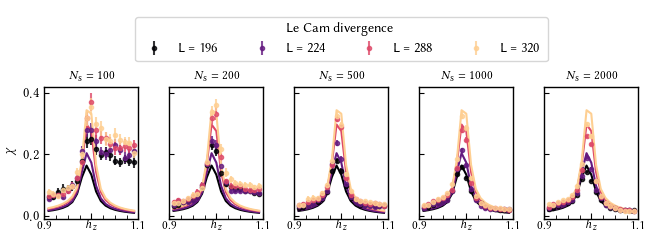

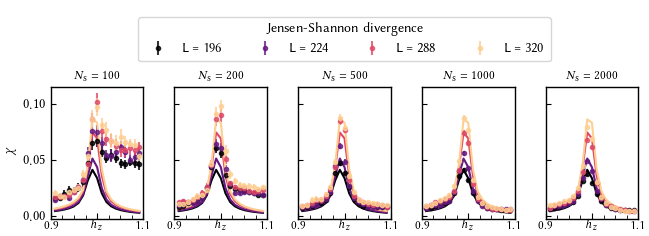

In [12]:
fig_width_cm = 16.5
fig_height_cm = 6.0
cm2inches = 1.0 / 2.54

# Keep original output naming/location used by manuscript workflow.
os.makedirs('./sm_figures', exist_ok=True)

axis_width = (fig_width_cm / max(num_sample_sizes, 1)) * cm2inches

for divergence in ('hellinger', 'triangular', 'jensen_shannon'):
    fig = plt.figure(
        constrained_layout=True,
        figsize=(axis_width * num_sample_sizes, fig_height_cm * cm2inches),
    )
    gridspec = fig.add_gridspec(2, num_sample_sizes, height_ratios=[0.1, 1.0])

    legend_ax = fig.add_subplot(gridspec[0, :])
    axes = [fig.add_subplot(gridspec[1, col_idx]) for col_idx in range(num_sample_sizes)]

    max_y = -np.inf
    min_y = np.inf

    for col_idx, samples_per_point in enumerate(sample_sizes):
        cur_ax = axes[col_idx]

        selected_exp_configs = [
            exp_config
            for exp_config in f_matrices_dict
            if exp_config.samples_per_point == samples_per_point
        ]

        colors = cm.get_cmap('magma')(np.linspace(0.0, 0.9, max(len(selected_exp_configs), 1)))

        for exp_config_idx, exp_config in enumerate(selected_exp_configs):
            f_matrix = f_matrices_dict[exp_config][divergence]
            f_matrix_std = f_matrices_std_dict[exp_config][divergence]

            # Estimate local susceptibility from nearest-neighbor distance diagonal.
            diag = pt.diag(f_matrix, diagonal=1)
            diag = 0.5 * (diag[1:] + diag[:-1])

            diag_std = pt.diag(f_matrix_std, diagonal=1)
            diag_std = 0.5 * (diag_std[1:] + diag_std[:-1])

            transverse_fields = np.asarray(coords_dict[exp_config])[:, 0]
            x_values = 0.5 * (transverse_fields[:-2] + transverse_fields[2:])

            cur_ax.set_title(r'$N_{\rm s}=' + str(samples_per_point) + '$', fontsize=LABEL_SIZE)
            cur_ax.errorbar(
                x_values,
                diag,
                yerr=diag_std,
                marker='o',
                ms=3,
                alpha=0.8,
                linestyle='',
                label=f'L = {exp_config.system_size}',
                color=colors[exp_config_idx],
            )

            cur_min_y, cur_max_y = cur_ax.get_ylim()
            max_y = max(max_y, cur_max_y)
            min_y = min(min_y, cur_min_y)

            if exp_config.system_size in system_size2overlaps:
                theor_dist_matrix = 2.0 * (1.0 - np.abs(system_size2overlaps[exp_config.system_size]))
                theor_dist_matrix = np.nan_to_num(theor_dist_matrix, nan=0.0)
                theor_diag = np.diag(theor_dist_matrix, k=1)
                theor_diag = 0.5 * (theor_diag[1:] + theor_diag[:-1])
                cur_ax.plot(
                    x_values,
                    divergence2theory_multiplier[divergence] * theor_diag,
                    label=f'L={exp_config.system_size}',
                    color=colors[exp_config_idx],
                )

    for col_idx, ax in enumerate(axes):
        ax.set_ylim(min_y, max_y)
        ax.tick_params(axis='x', direction='in')
        ax.tick_params(axis='y', direction='in')

        if col_idx != 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(r'$\chi$')

        compact_axes(
            ax,
            x_tex=r'$h_z$',
            xmin_label=0.9,
            xmax_label=1.1,
        )

    legend_handles, legend_labels = axes[0].get_legend_handles_labels()
    legend_ax.axis('off')
    # Keep only learned-series labels in legend (original behavior: skip first 4 handles).
    legend_ax.legend(
        legend_handles[4:],
        legend_labels[4:],
        loc='upper center',
        bbox_to_anchor=(0.5, 0.5),
        ncol=4,
        fontsize=10,
        title=f'{divergence2label[divergence]} divergence',
    )

    fig.savefig(
        f'./sm_figures/sm_figure_1_{divergence}.pdf',
        bbox_inches='tight',
        pad_inches=0.00,
    )
